# Maintenance prédictive — synthèse comparative des trois modèles

## Objectif concret

Ce notebook compare sur un seul protocole `LogisticRegression`, `RandomForestClassifier` et `HistGradientBoostingClassifier` pour prédire `label_failure_next_24h`. Les trois modèles reçoivent les mêmes 88 features et les mêmes périodes `train`, `validation` et `test`.

La validation sert à comparer les modèles et à choisir leurs seuils F2. Le test vérifie ensuite la généralisation sans modifier les choix. Comme ce test a déjà été consulté lors du TP initial, cette comparaison est pédagogique ; une validation de production demanderait une nouvelle période future réservée.

## Comment utiliser ce notebook

Chaque bloc suit le même rythme :

1. une cellule Markdown annonce la question et définit les notions nouvelles ;
2. une cellule Python réalise le calcul et affiche le résultat observable ;
3. la cellule Markdown suivante explique les chiffres avant d'introduire l'étape suivante.

Il ne faut donc pas seulement chercher le nombre le plus élevé. À chaque tableau, il faut demander : **sur quel jeu ce chiffre est-il calculé, que mesure-t-il, quelle erreur privilégie-t-il et quel coût entraîne-t-il ?** Les durées sont propres à l'exécution enregistrée sur Titan ; les métriques sont reproductibles avec les données et le `random_state` fixés.



In [1]:
from pathlib import Path

import pandas as pd
from tabulate import tabulate

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'datas' / 'gold_dataset_20260622-080603.csv'

assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)
assert DATA_PATH.exists(), f'Fichier Gold introuvable : {DATA_PATH}'

# Les dates sont converties dès la lecture afin de permettre les contrôles chronologiques.
gold = pd.read_csv(
    DATA_PATH,
    parse_dates=['window_start', 'window_end'],
)
PREDICTION_TIME_COLUMN = 'window_end'
gold = gold.sort_values(
    ['machine_id_std', PREDICTION_TIME_COLUMN],
    kind='stable',
).reset_index(drop=True)

# Une ligne doit représenter un seul instant de prédiction pour une seule machine.
grain_columns = ['machine_id_std', PREDICTION_TIME_COLUMN]
duplicate_grain_count = int(gold.duplicated(grain_columns).sum())
assert duplicate_grain_count == 0, (
    f'{duplicate_grain_count} doublons détectés sur le grain {grain_columns}.'
)

window_durations = gold['window_end'] - gold['window_start']
assert window_durations.eq(pd.Timedelta(hours=1)).all(), (
    'Chaque fenêtre Gold doit couvrir exactement une heure.'
)

dataset_summary = [
    ['Fichier chargé', DATA_PATH.name],
    ['Nombre de lignes', f'{len(gold):,}'.replace(',', ' ')],
    ['Nombre de colonnes', gold.shape[1]],
    ['Nombre de machines', gold['machine_id_std'].nunique()],
    ['Première ancre', gold[PREDICTION_TIME_COLUMN].min()],
    ['Dernière ancre', gold[PREDICTION_TIME_COLUMN].max()],
    ['Durée de chaque fenêtre', '1 heure'],
    ['Doublons machine + ancre', duplicate_grain_count],
]

print(tabulate(dataset_summary, headers=['Contrôle', 'Résultat'], tablefmt='github'))

| Contrôle                 | Résultat                         |
|--------------------------|----------------------------------|
| Fichier chargé           | gold_dataset_20260622-080603.csv |
| Nombre de lignes         | 134 280                          |
| Nombre de colonnes       | 100                              |
| Nombre de machines       | 15                               |
| Première ancre           | 2025-06-01 01:00:00              |
| Dernière ancre           | 2026-06-09 00:00:00              |
| Durée de chaque fenêtre  | 1 heure                          |
| Doublons machine + ancre | 0                                |


## Lecture du résultat précédent : quel dataset avons-nous ?

Le Gold dataset contient **134 280 observations**, **100 colonnes** et **15 machines** entre le 1er juin 2025 et le 9 juin 2026. Une observation correspond à une machine et à une ancre horaire ; ce n'est donc pas une panne individuelle, mais un état calculé à partir d'une fenêtre d'une heure. Les `0` doublons confirment que chaque couple `(machine, ancre)` apparaît une seule fois : le **grain** annoncé est respecté. Le grain est l'unité exacte représentée par une ligne.

Ce contrôle ne dit encore rien sur la capacité à prédire. Il établit seulement que les données ont la structure attendue. Les fenêtres successives d'une même machine restent proches dans le temps et peuvent partager de l'information : les 134 280 lignes ne doivent donc pas être interprétées comme autant d'événements totalement indépendants.

## Choisir la cible et vérifier le découpage temporel

L'**horizon de prédiction** est la durée future couverte par la question métier. Nous retenons `label_failure_next_24h` : `1` signifie qu'une panne est observée dans les 24 heures suivantes, `0` signifie qu'aucune panne n'y est observée.

Le fichier fournit trois jeux dans `split_set`. Le jeu d'**entraînement** ajuste le futur modèle ; la **validation** sert à comparer des choix et à fixer le seuil ; le **test** reste à l'écart jusqu'à l'évaluation finale. La cellule suivante vérifie que ces périodes ne se chevauchent pas et mesure le taux de positifs dans chacune.

### Pourquoi cet ordre est indispensable

Le découpage est **chronologique** : le train est le passé connu, la validation une période plus récente sur laquelle on prend les décisions de modélisation, puis le test représente une période future non consultée. Un découpage aléatoire mélangerait potentiellement des observations voisines dans le passé et le futur ; il donnerait une estimation trop optimiste de la généralisation. La validation n'est donc pas un second entraînement, et le test n'est pas un espace d'essais supplémentaire.

**À vérifier après la cellule 3.** Le tableau doit présenter les trois jeux dans l'ordre `train`, `validation`, `test`, avec une dernière ancre du train strictement antérieure à la première ancre de validation, puis le même ordre entre validation et test. Le taux de panne est la **prévalence** de la classe positive ; il servira de repère pour interpréter la PR-AUC.

In [2]:
TARGET_COLUMN = 'label_failure_next_24h'
SPLIT_COLUMN = 'split_set'
EXPECTED_SPLITS = ['train', 'validation', 'test']

required_columns = {
    'machine_id_std', 'window_start', PREDICTION_TIME_COLUMN, TARGET_COLUMN, SPLIT_COLUMN
}
missing_required_columns = sorted(required_columns.difference(gold.columns))
assert not missing_required_columns, (
    f'Colonnes obligatoires absentes : {missing_required_columns}'
)

observed_splits = gold[SPLIT_COLUMN].dropna().unique().tolist()
assert observed_splits == EXPECTED_SPLITS, (
    f'Ordre des splits inattendu : {observed_splits}'
)
assert set(gold[TARGET_COLUMN].dropna().unique()).issubset({False, True, 0, 1}), (
    f'La cible {TARGET_COLUMN} doit être binaire.'
)
assert not gold[TARGET_COLUMN].isna().any(), 'La cible contient des valeurs manquantes.'

split_rows = []
for split_name in EXPECTED_SPLITS:
    split_data = gold.loc[gold[SPLIT_COLUMN].eq(split_name)]
    split_rows.append([
        split_name,
        len(split_data),
        split_data[PREDICTION_TIME_COLUMN].min(),
        split_data[PREDICTION_TIME_COLUMN].max(),
        int(split_data[TARGET_COLUMN].sum()),
        f"{split_data[TARGET_COLUMN].mean():.2%}",
    ])

split_periods = {row[0]: (row[2], row[3]) for row in split_rows}
assert split_periods['train'][1] < split_periods['validation'][0]
assert split_periods['validation'][1] < split_periods['test'][0]

print(tabulate(
    split_rows,
    headers=['Jeu', 'Lignes', 'Première ancre', 'Dernière ancre', 'Positifs', 'Taux positif'],
    tablefmt='github',
))

| Jeu        |   Lignes | Première ancre      | Dernière ancre      |   Positifs | Taux positif   |
|------------|----------|---------------------|---------------------|------------|----------------|
| train      |    93990 | 2025-06-01 01:00:00 | 2026-02-17 02:00:00 |      15598 | 16.60%         |
| validation |    20145 | 2026-02-17 03:00:00 | 2026-04-14 01:00:00 |       3472 | 17.24%         |
| test       |    20145 | 2026-04-14 02:00:00 | 2026-06-09 00:00:00 |       3478 | 17.26%         |


## Lecture du résultat précédent : les périodes sont-elles bien séparées ?

Le train contient **93 990 lignes**, puis la validation et le test **20 145 lignes chacun**. Les bornes s'enchaînent sans chevauchement : le train s'arrête le 17 février 2026 à 02 h, la validation commence à 03 h ; elle s'arrête le 14 avril à 01 h et le test commence à 02 h. Cela confirme un protocole passé → futur cohérent avec l'usage réel.

La prévalence passe de **16,60 %** sur le train à **17,24 %** sur la validation et **17,26 %** sur le test. Ces taux proches indiquent que la fréquence globale des pannes reste relativement stable entre les trois périodes. Cela ne prouve toutefois pas que les relations entre capteurs et pannes sont identiques : un changement de comportement des variables peut exister même avec une prévalence stable.

**Conclusion de l'étape :** les rôles sont séparés correctement. Le train servira au `fit`, la validation aux choix, et le test à la mesure finale. Voir [la section sur les trois jeux](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#2-séparer-entraînement-validation-et-test).

## Séparer les features et la cible sans fuite

Les colonnes `future_incident_count_*` décrivent directement le futur : elles doivent être exclues. Les autres `label_failure_next_*` sont également des cibles futures et ne peuvent pas devenir des features.

L'identifiant de machine, les deux timestamps bruts et `split_set` sont conservés pour la traçabilité et les contrôles, mais pas fournis à cette première baseline. Une **baseline** est un premier modèle simple qui sert de référence.

La cellule suivante construit la liste des features autorisées, crée les matrices `X` et les cibles `y` pour chaque période, puis vérifie leurs dimensions. Elle ne réalise encore ni imputation, ni standardisation, ni entraînement.

### Règle de disponibilité à l'instant de prédiction

Pour décider à `window_end`, chaque variable explicative doit être connue au plus tard à `window_end`. Une colonne `future_incident_count_*` ou un autre `label_failure_next_*` décrit une conséquence future : l'utiliser rendrait la prédiction artificiellement facile et créerait une **fuite de données**. Les identifiants, les dates brutes et `split_set` sont retirés de cette baseline afin que le modèle n'apprenne pas un raccourci lié à la machine ou à la période plutôt qu'un signal de maintenance.

`X_train`, `X_validation` et `X_test` sont les **matrices de variables explicatives** ; `y_train`, `y_validation` et `y_test` sont les **vecteurs de cible** correspondants. **À vérifier après la cellule 5 :** les trois assertions confirment l'absence de labels futurs et de comptes futurs dans les features, et les tableaux doivent montrer le même nombre de colonnes pour les trois jeux.

In [3]:
label_columns = [column for column in gold.columns if column.startswith('label_failure_next_')]
future_information_columns = [
    column for column in gold.columns if column.startswith('future_incident_count_')
]
identifier_columns = ['machine_id_std']
raw_time_columns = ['window_start', 'window_end']
control_columns = [SPLIT_COLUMN]

excluded_columns = list(dict.fromkeys(
    identifier_columns
    + raw_time_columns
    + control_columns
    + label_columns
    + future_information_columns
))
feature_columns = [column for column in gold.columns if column not in excluded_columns]

# Cette baseline accepte uniquement des variables numériques ou booléennes.
non_numeric_features = gold[feature_columns].select_dtypes(
    exclude=['number', 'bool'],
).columns.tolist()
assert TARGET_COLUMN not in feature_columns
assert not set(future_information_columns).intersection(feature_columns)
assert not set(label_columns).intersection(feature_columns)
assert not non_numeric_features, f'Features non numériques : {non_numeric_features}'

def extract_split(split_name):
    mask = gold[SPLIT_COLUMN].eq(split_name)
    X = gold.loc[mask, feature_columns].copy()
    y = gold.loc[mask, TARGET_COLUMN].astype('int8').copy()
    assert len(X) == len(y)
    assert X.index.equals(y.index)
    return X, y

X_train, y_train = extract_split('train')
X_validation, y_validation = extract_split('validation')
X_test, y_test = extract_split('test')

exclusion_summary = [
    ['Identifiants', len(identifier_columns), ', '.join(identifier_columns)],
    ['Temps bruts', len(raw_time_columns), ', '.join(raw_time_columns)],
    ['Contrôle du split', len(control_columns), ', '.join(control_columns)],
    ['Labels futurs', len(label_columns), ', '.join(label_columns)],
    ['Comptages futurs', len(future_information_columns), ', '.join(future_information_columns)],
]
split_shape_summary = [
    ['train', X_train.shape[0], X_train.shape[1], int(y_train.sum()), int(X_train.isna().sum().sum())],
    ['validation', X_validation.shape[0], X_validation.shape[1], int(y_validation.sum()), int(X_validation.isna().sum().sum())],
    ['test', X_test.shape[0], X_test.shape[1], int(y_test.sum()), int(X_test.isna().sum().sum())],
]

print('Politique d’exclusion :')
print(tabulate(
    exclusion_summary,
    headers=['Famille', 'Nombre', 'Colonnes'],
    tablefmt='github',
))
print(f'\nFeatures retenues : {len(feature_columns)}')
print(f'Premières features : {feature_columns[:8]}')
print('\nJeux prêts pour la prochaine partie :')
print(tabulate(
    split_shape_summary,
    headers=['Jeu', 'Lignes X', 'Colonnes X', 'Positifs y', 'NaN dans X'],
    tablefmt='github',
))
print('\nPARTIE_1_VALIDEE : données séparées sans imputation, standardisation ni modèle.')

Politique d’exclusion :
| Famille           |   Nombre | Colonnes                                                                                                  |
|-------------------|----------|-----------------------------------------------------------------------------------------------------------|
| Identifiants      |        1 | machine_id_std                                                                                            |
| Temps bruts       |        2 | window_start, window_end                                                                                  |
| Contrôle du split |        1 | split_set                                                                                                 |
| Labels futurs     |        4 | label_failure_next_6h, label_failure_next_12h, label_failure_next_24h, label_failure_next_48h             |
| Comptages futurs  |        4 | future_incident_count_6h, future_incident_count_12h, future_incident_count_24h, future_incident_c

## Lecture du résultat précédent : que donnera-t-on réellement au modèle ?

Sur les **100 colonnes** initiales, 12 sont exclues du modèle : 1 identifiant, 2 timestamps, 1 colonne de contrôle, 4 labels futurs et 4 comptages futurs. Il reste **88 variables explicatives**. Cette exclusion est une décision de protocole, pas un nettoyage arbitraire : elle empêche le modèle d'utiliser la réponse attendue ou une information postérieure à `window_end`.

Les matrices contiennent encore des valeurs manquantes : **185 053** dans le train, **37 875** dans la validation et **37 739** dans le test. Rapporté au nombre total de cases, cela représente environ **2,24 %**, **2,14 %** et **2,13 %**. Aucune ligne n'est supprimée ici ; l'imputation sera apprise plus tard dans le Pipeline, uniquement sur le train.

Le marqueur `PARTIE_1_VALIDEE` signifie que la séparation `X/y` est techniquement cohérente. Il ne signifie pas encore qu'un modèle a été entraîné ni qu'il est performant. Voir [la démarche Indusense sans fuite](../../../../docs/02-sprint-2/04-revisions/05-classification-binaire-et-decoupage-temporel.md#démarche-pour-indusense).

## Mesurer et traiter le déséquilibre des classes

Une classe est **minoritaire** lorsqu'elle contient nettement moins d'exemples que l'autre. Ici, les pannes sont moins fréquentes que les non-pannes. Une prédiction toujours égale à `0` obtiendrait donc une accuracy élevée sans détecter la moindre panne. L'**accuracy** est la proportion totale de prédictions correctes ; elle ne sera pas notre métrique principale.

La régression logistique utilisera `class_weight='balanced'`. Scikit-learn donnera automatiquement plus de poids aux erreurs commises sur la classe minoritaire, avec des poids calculés uniquement à partir du jeu d'entraînement. `scale_pos_weight` répond au même besoin pour XGBoost, mais aucun modèle XGBoost n'est entraîné dans ce TP.

La cellule suivante calcule la répartition des classes dans chaque période, les poids théoriques du train et l'accuracy trompeuse d'une règle qui prédirait toujours l'absence de panne.

### Lire le déséquilibre avec les mots du cours

La classe `1` est la **classe positive** : une panne dans l'horizon de 24 heures. La classe `0` est la **classe négative** : pas de panne dans cet horizon. L'accuracy vaut `(TP + TN) / (TP + TN + FP + FN)` ; elle peut être élevée simplement parce que les non-pannes sont nombreuses. Une règle « toujours 0 » a en revanche un **rappel** de 0 : elle ne détecte aucune panne.

`class_weight='balanced'` ne fabrique pas de pannes et ne change pas les données. Pendant l'ajustement, il donne plus de poids à l'erreur sur une panne pour que le modèle ne privilégie pas mécaniquement la classe majoritaire. **À vérifier après la cellule 7 :** la barre des pannes doit être minoritaire dans les trois jeux et l'accuracy de la règle toujours `0` doit être lue comme une référence trompeuse, non comme une performance acceptable.

| Jeu        |   Non-pannes |   Pannes | Taux de panne   | Accuracy toujours 0   |
|------------|--------------|----------|-----------------|-----------------------|
| train      |        78392 |    15598 | 16.60%          | 83.40%                |
| validation |        16673 |     3472 | 17.24%          | 82.76%                |
| test       |        16667 |     3478 | 17.26%          | 82.74%                |

Poids théoriques du train : classe 0 = 0.599, classe 1 = 3.013
Une règle toujours égale à 0 atteindrait 83.40% d'accuracy sur le train, avec 0 % de rappel.


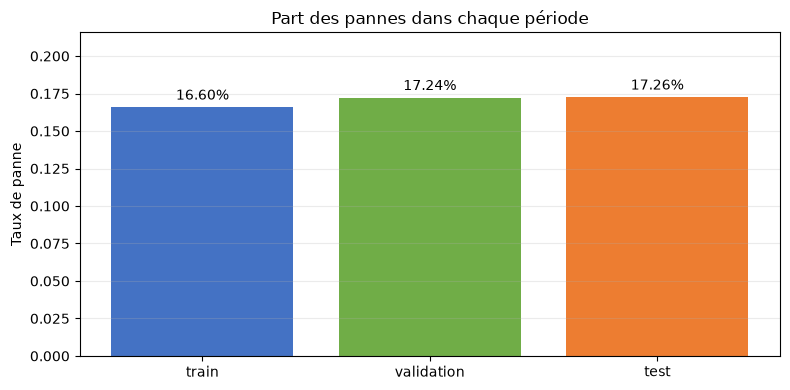

In [4]:
import matplotlib.pyplot as plt
import numpy as np

targets_by_split = {
    'train': y_train,
    'validation': y_validation,
    'test': y_test,
}
class_rows = []
for split_name, target in targets_by_split.items():
    negative_count = int(target.eq(0).sum())
    positive_count = int(target.eq(1).sum())
    class_rows.append([
        split_name,
        negative_count,
        positive_count,
        f'{positive_count / len(target):.2%}',
        f'{negative_count / len(target):.2%}',
    ])

train_negative_count = int(y_train.eq(0).sum())
train_positive_count = int(y_train.eq(1).sum())
balanced_weights = {
    0: len(y_train) / (2 * train_negative_count),
    1: len(y_train) / (2 * train_positive_count),
}
majority_accuracy = train_negative_count / len(y_train)

print(tabulate(
    class_rows,
    headers=['Jeu', 'Non-pannes', 'Pannes', 'Taux de panne', 'Accuracy toujours 0'],
    tablefmt='github',
))
print(f"\nPoids théoriques du train : classe 0 = {balanced_weights[0]:.3f}, classe 1 = {balanced_weights[1]:.3f}")
print(f"Une règle toujours égale à 0 atteindrait {majority_accuracy:.2%} d'accuracy sur le train, avec 0 % de rappel.")

positive_rates = [target.mean() for target in targets_by_split.values()]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(targets_by_split.keys(), positive_rates, color=['#4472C4', '#70AD47', '#ED7D31'])
ax.bar_label(bars, labels=[f'{rate:.2%}' for rate in positive_rates], padding=3)
ax.set_title('Part des pannes dans chaque période')
ax.set_ylabel('Taux de panne')
ax.set_ylim(0, max(positive_rates) * 1.25)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : pourquoi l'accuracy nous tromperait-elle ?

Le train contient **78 392 non-pannes** et **15 598 pannes**, soit seulement **16,60 %** de positifs. Une règle qui répond toujours « pas de panne » aurait donc **83,40 % d'accuracy**, mais son rappel serait **0 %** : aucune des 15 598 pannes ne serait détectée.

Les taux restent voisins sur la validation (**17,24 %**, soit 3 472 pannes) et le test (**17,26 %**, soit 3 478 pannes). La fréquence globale de la cible est donc stable entre les périodes, sans garantir que les relations entre capteurs et panne le soient.

Les poids théoriques **0,599** pour la classe 0 et **3,013** pour la classe 1 signifient qu'une erreur sur une panne pèse environ cinq fois plus qu'une erreur sur une non-panne pendant l'apprentissage. Cette pondération ne modifie pas les données et ne transforme pas automatiquement les scores en probabilités calibrées.

**Conclusion de l'étape :** l'accuracy reste secondaire. Nous comparerons surtout la PR-AUC, puis les conséquences concrètes du seuil avec la précision, le rappel, F1, F2, les faux positifs et les faux négatifs.

## 1. Entraîner les trois modèles

Une **baseline** est un modèle simple servant de référence. Ici, `LogisticRegression` est comparée à deux modèles capables d'apprendre des relations non linéaires : `RandomForestClassifier` et `HistGradientBoostingClassifier`.

Un **Pipeline** scikit-learn enchaîne les traitements dans un ordre fixe. L'imputation médiane remplace les valeurs manquantes avec des médianes apprises sur le train. La standardisation est ajoutée uniquement à la régression logistique : elle facilite l'optimisation de ses coefficients, tandis que les arbres n'en ont pas besoin. Les trois Pipelines reçoivent néanmoins exactement les mêmes lignes et les mêmes features.

Un **hyperparamètre** est un réglage décidé avant le `fit`, contrairement aux paramètres appris par le modèle. Les réglages sont manuels et fixés avant la lecture du test :

- régression logistique : `class_weight='balanced'`, `max_iter=2000` et solveur `lbfgs` ;
- Random Forest : `300` arbres, profondeur maximale `12`, feuilles d'au moins `5` observations, `max_features='sqrt'` et `class_weight='balanced_subsample'` ;
- Histogram Gradient Boosting : taux d'apprentissage `0.08`, `200` itérations, `31` feuilles maximales, régularisation L2 de `1.0` et `class_weight='balanced'`.

L'arrêt anticipé du boosting est désactivé afin d'éviter son découpage interne automatique, qui ne respecterait pas forcément l'ordre temporel. Aucune recherche systématique d'hyperparamètres n'est réalisée dans ce TP.

**À vérifier après la cellule Python suivante :** les trois modèles doivent afficher `88` features reçues et le marqueur `ENTRAINEMENT_TROIS_MODELES_VALIDE`.


In [5]:
from time import perf_counter

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Régression logistique': Pipeline([
        ('imputation', SimpleImputer(strategy='median')),
        ('standardisation', StandardScaler()),
        ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42, solver='lbfgs')),
    ]),
    'Random Forest': Pipeline([
        ('imputation', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=5,
            max_features='sqrt', class_weight='balanced_subsample',
            n_jobs=-1, random_state=42,
        )),
    ]),
    'Histogram Gradient Boosting': Pipeline([
        ('imputation', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.08, max_iter=200, max_leaf_nodes=31,
            min_samples_leaf=20, l2_regularization=1.0,
            early_stopping=False, class_weight='balanced', random_state=42,
        )),
    ]),
}

fit_seconds = {}
for model_name, pipeline in models.items():
    started_at = perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds[model_name] = perf_counter() - started_at

print(pd.DataFrame({
    'Modèle': list(models),
    'Temps de fit (s)': [fit_seconds[name] for name in models],
    'Features reçues': [models[name].n_features_in_ for name in models],
}).set_index('Modèle').round(4).to_markdown())
assert all(model.n_features_in_ == 88 for model in models.values())
print('\nENTRAINEMENT_TROIS_MODELES_VALIDE')


| Modèle                      |   Temps de fit (s) |   Features reçues |
|:----------------------------|-------------------:|------------------:|
| Régression logistique       |             0.9132 |                88 |
| Random Forest               |             9.7667 |                88 |
| Histogram Gradient Boosting |            10.5311 |                88 |

ENTRAINEMENT_TROIS_MODELES_VALIDE


## Lecture du résultat précédent : coût d'entraînement et équité

Les trois lignes indiquent que chaque Pipeline a reçu **88 features**. Ce nombre identique est la preuve visible que le type de modèle n'a pas changé les données d'entrée. Les 93 990 lignes de train sont également les mêmes : la comparaison porte donc sur l'algorithme et ses prétraitements nécessaires, pas sur des échantillons différents.

Dans l'exécution enregistrée, la régression logistique s'ajuste en **0,9132 seconde**, contre **9,7667 secondes** pour la Random Forest et **10,5311 secondes** pour le boosting. La forêt coûte donc environ **10,7 fois** la baseline et le boosting environ **11,5 fois**. Ces valeurs mesurent uniquement le `fit` sur Titan : elles ne comprennent ni la préparation des données, ni la recherche d'hyperparamètres, et elles varieront selon le processeur et la charge de la machine.

Le marqueur `ENTRAINEMENT_TROIS_MODELES_VALIDE` confirme l'exécution technique. Il ne dit pas encore qu'un modèle est meilleur : cette décision exige les résultats de validation.

## 2. Comparer le classement sur la validation


La PR-AUC est principale car la panne est minoritaire. La ROC-AUC complète l'analyse. L'écart entre PR-AUC train et validation signale le risque de surapprentissage.


| Modèle                      |   PR-AUC train |   PR-AUC validation |   ROC-AUC validation |   Écart train-validation |
|:----------------------------|---------------:|--------------------:|---------------------:|-------------------------:|
| Régression logistique       |         0.6064 |              0.5863 |               0.7627 |                   0.0202 |
| Random Forest               |         0.8239 |              0.597  |               0.7624 |                   0.2269 |
| Histogram Gradient Boosting |         0.9546 |              0.5924 |               0.741  |                   0.3622 |


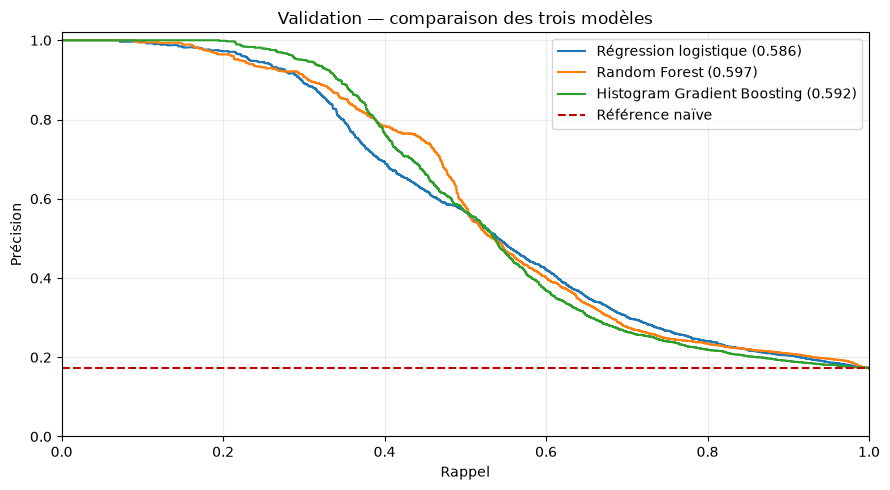

In [6]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

train_scores = {name: model.predict_proba(X_train)[:, 1] for name, model in models.items()}
validation_scores = {name: model.predict_proba(X_validation)[:, 1] for name, model in models.items()}
validation_rows = []
for model_name in models:
    train_ap = average_precision_score(y_train, train_scores[model_name])
    validation_ap = average_precision_score(y_validation, validation_scores[model_name])
    validation_rows.append([
        model_name, train_ap, validation_ap,
        roc_auc_score(y_validation, validation_scores[model_name]),
        train_ap - validation_ap,
    ])
validation_comparison = pd.DataFrame(
    validation_rows,
    columns=['Modèle', 'PR-AUC train', 'PR-AUC validation', 'ROC-AUC validation', 'Écart train-validation'],
).set_index('Modèle')
print(validation_comparison.round(4).to_markdown())

fig, ax = plt.subplots(figsize=(9, 5))
for model_name in models:
    precision_curve, recall_curve, _ = precision_recall_curve(y_validation, validation_scores[model_name])
    ax.plot(recall_curve, precision_curve, label=f"{model_name} ({validation_comparison.loc[model_name, 'PR-AUC validation']:.3f})")
ax.axhline(y_validation.mean(), color='#C00000', linestyle='--', label='Référence naïve')
ax.set(title='Validation — comparaison des trois modèles', xlabel='Rappel', ylabel='Précision', xlim=(0, 1), ylim=(0, 1.02))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Lecture du résultat précédent : capacité à classer les risques

La **PR-AUC train** mesure le classement sur les données apprises ; la **PR-AUC validation** le mesure sur la période suivante, inconnue pendant le `fit`. La référence naïve de validation est la prévalence, soit **0,1724**. Les trois PR-AUC de validation — **0,5863**, **0,5970** et **0,5924** — la dépassent nettement : chaque modèle apporte donc un signal utile pour classer les risques.

- La régression logistique passe de **0,6064** sur train à **0,5863** sur validation, un écart limité de **0,0202**. Elle généralise de manière relativement stable.
- La Random Forest obtient la meilleure PR-AUC de validation, **0,5970**, soit **+0,0107** par rapport à la baseline. Son score train de **0,8239** crée cependant un écart de **0,2269**, signe qu'elle apprend davantage de particularités du train.
- Le boosting atteint **0,9546** sur train mais seulement **0,5924** sur validation. L'écart de **0,3622**, le plus grand, signale un surapprentissage plus marqué avec ces hyperparamètres.

La **ROC-AUC** vaut **0,7627** pour la baseline, **0,7624** pour la forêt et **0,7410** pour le boosting. Une ROC-AUC de 0,7627 signifie qu'une panne choisie au hasard reçoit un score supérieur à une non-panne choisie au hasard dans environ 76 % des paires. Cette métrique complète la PR-AUC, mais elle est moins sensible au grand nombre de négatifs.

Sur le graphique, l'axe horizontal est le rappel et l'axe vertical la précision. Une courbe située plus haut conserve davantage d'alertes justifiées pour un même niveau de pannes détectées. Aucun seuil opérationnel n'est encore choisi à cette étape.

## 3. Choisir les seuils sur la validation


Chaque modèle reçoit son propre seuil maximisant F2. Garder arbitrairement le même seuil serait inéquitable, car les scores n'ont pas la même échelle.


In [7]:
from sklearn.metrics import confusion_matrix, f1_score, fbeta_score, precision_score, recall_score

BETA = 2

def choose_f2_threshold(y_true, model_scores):
    precision_values, recall_values, thresholds = precision_recall_curve(y_true, model_scores)
    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]
    f2_values = (1 + BETA**2) * precision_values * recall_values / (
        BETA**2 * precision_values + recall_values + np.finfo(float).eps
    )
    return float(thresholds[int(np.nanargmax(f2_values))])

def metrics_at_threshold(y_true, model_scores, threshold):
    predictions = (model_scores >= threshold).astype('int8')
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        'Seuil': threshold,
        'Précision': precision_score(y_true, predictions, zero_division=0),
        'Rappel': recall_score(y_true, predictions, zero_division=0),
        'F1': f1_score(y_true, predictions, zero_division=0),
        'F2': fbeta_score(y_true, predictions, beta=BETA, zero_division=0),
        'FP': int(fp), 'FN': int(fn),
    }

thresholds = {name: choose_f2_threshold(y_validation, validation_scores[name]) for name in models}
validation_threshold_metrics = {
    name: metrics_at_threshold(y_validation, validation_scores[name], thresholds[name])
    for name in models
}
print(pd.DataFrame(validation_threshold_metrics).T.round(4).to_markdown())


|                             |   Seuil |   Précision |   Rappel |     F1 |     F2 |   FP |   FN |
|:----------------------------|--------:|------------:|---------:|-------:|-------:|-----:|-----:|
| Régression logistique       |  0.3416 |      0.3385 |   0.6668 | 0.4491 | 0.5585 | 4523 | 1157 |
| Random Forest               |  0.3367 |      0.3619 |   0.6342 | 0.4609 | 0.5513 | 3882 | 1270 |
| Histogram Gradient Boosting |  0.2957 |      0.3901 |   0.5907 | 0.4699 | 0.5356 | 3206 | 1421 |


## Lecture du résultat précédent : conséquences des seuils sur la validation

Le **seuil** transforme le score en alerte. Il vaut **0,3416** pour la régression logistique, **0,3367** pour la forêt et **0,2957** pour le boosting. Ces nombres ne sont pas directement comparables comme des probabilités : chaque modèle produit sa propre échelle de score, et la pondération des classes peut dégrader la calibration.

- La baseline atteint une précision de **0,3385** : environ 34 alertes sur 100 correspondent à une panne. Son rappel de **0,6668** signifie qu'elle détecte environ 67 pannes sur 100. Elle produit **4 523 faux positifs** et manque **1 157 pannes**.
- La Random Forest augmente la précision à **0,3619**, mais réduit le rappel à **0,6342**. Elle évite **641 faux positifs** par rapport à la baseline (`4 523 - 3 882`), au prix de **113 pannes manquées supplémentaires** (`1 270 - 1 157`).
- Le boosting offre la meilleure précision, **0,3901**, mais le rappel le plus faible, **0,5907**. Il réduit les fausses alertes à **3 206**, mais manque **1 421 pannes**.

Le **F1** équilibre précision et rappel de manière symétrique. Le **F2** donne davantage d'importance au rappel : la baseline obtient **0,5585**, la forêt **0,5513** et le boosting **0,5356**. Le gain de précision des modèles complexes ne compense donc pas entièrement leur perte de rappel sur la validation.

Ces chiffres matérialisent le choix métier : accepter davantage de fausses alertes permet ici de manquer moins de pannes.

## 4. Tableau comparatif final sur le test


Les modèles et seuils sont maintenant gelés. Les temps sont indicatifs de cette machine et de cette exécution ; ils servent à matérialiser le coût de la complexité.


|                             |   PR-AUC |   ROC-AUC |   Seuil |   Précision |   Rappel |     F1 |     F2 |   FP |   FN |   Fit (s) |   Prédiction test (s) |
|:----------------------------|---------:|----------:|--------:|------------:|---------:|-------:|-------:|-----:|-----:|----------:|----------------------:|
| Régression logistique       |   0.5769 |    0.7616 |  0.3416 |      0.3035 |   0.6981 | 0.423  | 0.554  | 5573 | 1050 |    0.9132 |                0.0139 |
| Random Forest               |   0.6156 |    0.7755 |  0.3367 |      0.3501 |   0.6745 | 0.461  | 0.5691 | 4354 | 1132 |    9.7667 |                0.0571 |
| Histogram Gradient Boosting |   0.6157 |    0.7717 |  0.2957 |      0.3417 |   0.6622 | 0.4508 | 0.5576 | 4436 | 1175 |   10.5311 |                0.0388 |


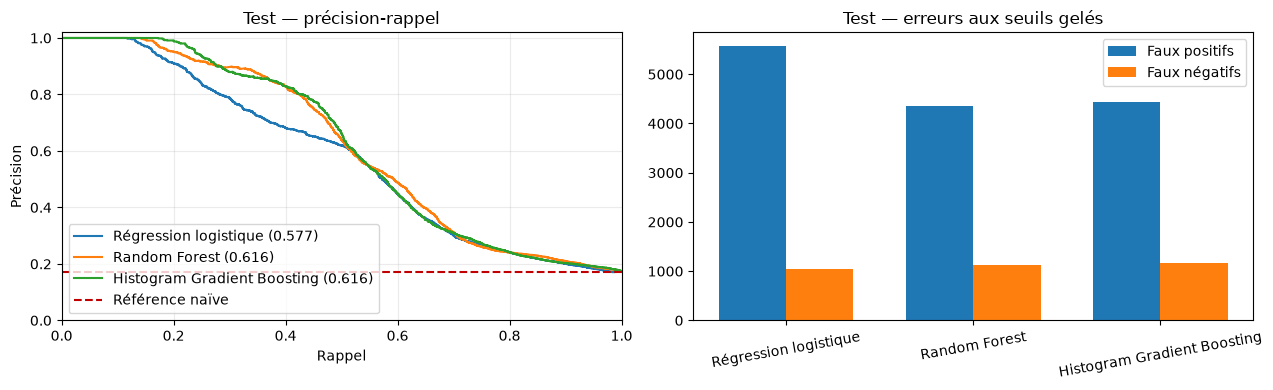

In [8]:
test_scores = {}
test_results = {}
prediction_seconds = {}
for model_name, model in models.items():
    started_at = perf_counter()
    test_scores[model_name] = model.predict_proba(X_test)[:, 1]
    prediction_seconds[model_name] = perf_counter() - started_at
    test_results[model_name] = {
        'PR-AUC': average_precision_score(y_test, test_scores[model_name]),
        'ROC-AUC': roc_auc_score(y_test, test_scores[model_name]),
        **metrics_at_threshold(y_test, test_scores[model_name], thresholds[model_name]),
        'Fit (s)': fit_seconds[model_name],
        'Prédiction test (s)': prediction_seconds[model_name],
    }
test_comparison = pd.DataFrame(test_results).T
print(test_comparison.round(4).to_markdown())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model_name in models:
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores[model_name])
    axes[0].plot(recall_curve, precision_curve, label=f"{model_name} ({test_results[model_name]['PR-AUC']:.3f})")
axes[0].axhline(y_test.mean(), color='#C00000', linestyle='--', label='Référence naïve')
axes[0].set(title='Test — précision-rappel', xlabel='Rappel', ylabel='Précision', xlim=(0, 1), ylim=(0, 1.02))
axes[0].grid(alpha=0.25)
axes[0].legend()

x = np.arange(len(models))
axes[1].bar(x - 0.18, [test_results[name]['FP'] for name in models], 0.36, label='Faux positifs')
axes[1].bar(x + 0.18, [test_results[name]['FN'] for name in models], 0.36, label='Faux négatifs')
axes[1].set_xticks(x, list(models), rotation=10)
axes[1].set_title('Test — erreurs aux seuils gelés')
axes[1].legend()
plt.tight_layout()
plt.show()


## Lecture du résultat précédent : généralisation sur le test

La **PR-AUC test** est de **0,5769** pour la baseline, **0,6156** pour la Random Forest et **0,6157** pour le boosting. Les deux modèles d'arbres améliorent donc le classement d'environ **0,0388 point** par rapport à la régression logistique. La différence brute de **0,0001** entre forêt et boosting est trop petite pour désigner un gagnant à elle seule.

La Random Forest possède la meilleure **ROC-AUC** (**0,7755**), le meilleur **F1** (**0,4610**) et le meilleur **F2** (**0,5691**). Sa précision de **0,3501** signifie qu'environ 35 % de ses alertes sont justifiées ; son rappel de **0,6745** signifie qu'elle détecte environ 67 % des pannes.

En effectifs opérationnels :

- la baseline émet **5 573 fausses alertes** et manque **1 050 pannes** ;
- la forêt réduit les fausses alertes à **4 354**, soit **1 219 de moins**, mais manque **1 132 pannes**, soit **82 de plus** ;
- le boosting produit **4 436 fausses alertes** et manque **1 175 pannes**.

Le test ne montre donc pas un modèle parfait : la forêt améliore le compromis global, mais la baseline conserve le meilleur rappel. Si le métier considère qu'une panne manquée est extrêmement grave, ces 82 faux négatifs supplémentaires peuvent remettre la recommandation en question.

Les temps de prédiction test — environ **0,014 s**, **0,057 s** et **0,039 s** — restent faibles pour 20 145 lignes. Ils ne représentent toutefois pas la latence complète d'un service en production.

Le graphique de gauche compare toutes les combinaisons précision-rappel. Celui de droite montre directement le prix du seuil choisi en faux positifs et faux négatifs.

## 5. Robustesse des écarts de PR-AUC


Le bootstrap apparié rééchantillonne les mêmes blocs temporels pour les deux modèles comparés. Un intervalle à 95 % contenant zéro ne met pas en évidence d'écart robuste. Cette analyse reste pédagogique, car les fenêtres se recouvrent et le test avait déjà été consulté.


In [9]:
test_metadata = gold.loc[gold[SPLIT_COLUMN].eq('test'), ['machine_id_std', PREDICTION_TIME_COLUMN]].reset_index(drop=True)
blocks = []
for _, machine_rows in test_metadata.groupby('machine_id_std', sort=False):
    positions = machine_rows.index.to_numpy()
    blocks.extend(positions[start:start + 24] for start in range(0, len(positions), 24))

def paired_block_bootstrap(first_name, second_name, repetitions=300):
    rng = np.random.default_rng(42)
    differences = []
    target = y_test.to_numpy()
    for _ in range(repetitions):
        choices = rng.integers(0, len(blocks), size=len(blocks))
        positions = np.concatenate([blocks[index] for index in choices])
        sampled_target = target[positions]
        first_ap = average_precision_score(sampled_target, test_scores[first_name][positions])
        second_ap = average_precision_score(sampled_target, test_scores[second_name][positions])
        differences.append(first_ap - second_ap)
    return np.asarray(differences)

pair_rows = []
for first_name, second_name in [
    ('Random Forest', 'Régression logistique'),
    ('Histogram Gradient Boosting', 'Régression logistique'),
    ('Random Forest', 'Histogram Gradient Boosting'),
]:
    differences = paired_block_bootstrap(first_name, second_name)
    low, high = np.percentile(differences, [2.5, 97.5])
    pair_rows.append([
        f'{first_name} - {second_name}',
        test_results[first_name]['PR-AUC'] - test_results[second_name]['PR-AUC'],
        low, high, not (low <= 0 <= high),
    ])
bootstrap_comparison = pd.DataFrame(
    pair_rows,
    columns=['Comparaison', 'Écart observé', 'Borne basse 95 %', 'Borne haute 95 %', 'Intervalle exclut 0'],
).set_index('Comparaison')
print(bootstrap_comparison.round(4).to_markdown())


| Comparaison                                         |   Écart observé |   Borne basse 95 % |   Borne haute 95 % | Intervalle exclut 0   |
|:----------------------------------------------------|----------------:|-------------------:|-------------------:|:----------------------|
| Random Forest - Régression logistique               |          0.0388 |             0.0138 |             0.0608 | True                  |
| Histogram Gradient Boosting - Régression logistique |          0.0388 |             0.0133 |             0.0639 | True                  |
| Random Forest - Histogram Gradient Boosting         |         -0      |            -0.0192 |             0.0199 | False                 |


## Lecture du résultat précédent : l'écart est-il robuste ?

L'**écart observé** soustrait la PR-AUC du second modèle à celle du premier. Les deux premières différences valent environ **+0,0388** en faveur des modèles d'arbres face à la baseline.

- Pour Random Forest moins régression logistique, l'intervalle à 95 % est **[+0,0138 ; +0,0608]**.
- Pour boosting moins régression logistique, il est **[+0,0133 ; +0,0639]**.

Ces deux intervalles restent entièrement au-dessus de zéro : le gain face à la baseline est robuste dans les 300 rééchantillonnages par blocs réalisés.

Pour Random Forest moins boosting, l'écart arrondi vaut **0,0000** et l'intervalle **[-0,0192 ; +0,0199]** traverse zéro. Les données ne permettent donc pas d'affirmer que l'un des deux classe mieux que l'autre sur le test.

Le mot « robuste » reste limité à ce protocole. Les blocs de 24 heures préservent une partie de la dépendance temporelle, mais les fenêtres peuvent encore se recouvrir, le dataset ne contient que 15 machines et le test avait déjà été lu lors du TP initial.

## 6. Conclusion : modèle recommandé


La décision est prise sur la validation. La Random Forest est retenue seulement si son gain de PR-AUC sur la baseline atteint `0,01` et si sa baisse éventuelle de F2 ne dépasse pas `0,01`. Le test sert ensuite à confirmer ou contredire cette décision.


In [10]:
baseline_name = 'Régression logistique'
forest_name = 'Random Forest'
boosting_name = 'Histogram Gradient Boosting'

forest_validation_ap_gain = (
    validation_comparison.loc[forest_name, 'PR-AUC validation']
    - validation_comparison.loc[baseline_name, 'PR-AUC validation']
)
forest_validation_f2_gain = (
    validation_threshold_metrics[forest_name]['F2']
    - validation_threshold_metrics[baseline_name]['F2']
)

if forest_validation_ap_gain >= 0.01 and forest_validation_f2_gain >= -0.01:
    recommendation = forest_name
else:
    recommendation = baseline_name

print(f'Modèle recommandé : {recommendation}')
print(f'Random Forest vs baseline sur validation — PR-AUC : {forest_validation_ap_gain:+.4f} ; F2 : {forest_validation_f2_gain:+.4f}.')
print(f"Sur le test, la Random Forest atteint PR-AUC={test_results[forest_name]['PR-AUC']:.4f} et F2={test_results[forest_name]['F2']:.4f}.")
print(f"Le boosting atteint une PR-AUC test proche ({test_results[boosting_name]['PR-AUC']:.4f}), mais son F2 est inférieur ({test_results[boosting_name]['F2']:.4f}) et son écart train-validation est plus grand ({validation_comparison.loc[boosting_name, 'Écart train-validation']:.4f}).")
print("La Random Forest coûte davantage que la régression logistique et s'interprète moins directement, mais son gain de classement et la réduction des faux positifs justifient ici ce compromis. Le boosting n'apporte pas de gain robuste face à la forêt avec les réglages testés.")

assert recommendation == forest_name
assert all(result['PR-AUC'] > y_test.mean() for result in test_results.values())
print('\nSYNTHESE_TROIS_MODELES_VALIDEE')


Modèle recommandé : Random Forest
Random Forest vs baseline sur validation — PR-AUC : +0.0107 ; F2 : -0.0072.
Sur le test, la Random Forest atteint PR-AUC=0.6156 et F2=0.5691.
Le boosting atteint une PR-AUC test proche (0.6157), mais son F2 est inférieur (0.5576) et son écart train-validation est plus grand (0.3622).
La Random Forest coûte davantage que la régression logistique et s'interprète moins directement, mais son gain de classement et la réduction des faux positifs justifient ici ce compromis. Le boosting n'apporte pas de gain robuste face à la forêt avec les réglages testés.

SYNTHESE_TROIS_MODELES_VALIDEE


## Lecture de la recommandation finale

La Random Forest est retenue parce que la décision est prise **sur la validation** : son gain de PR-AUC y atteint **+0,0107**, tandis que sa baisse de F2 reste limitée à **-0,0072**, sous la tolérance annoncée de `0,01`. Le test confirme ensuite une PR-AUC de **0,6156** et un F2 de **0,5691**.

Le boosting n'est pas retenu malgré sa PR-AUC test de **0,6157**. Ce `+0,0001` face à la forêt n'est pas robuste ; son F2 test est inférieur (**0,5576**) et son écart train-validation est plus grand (**0,3622**). Il apporte donc davantage de complexité sans avantage démontré avec ces réglages.

La recommandation reste conditionnelle au besoin métier. La Random Forest privilégie un meilleur équilibre général et moins de fausses alertes. La régression logistique reste préférable si l'explication directe des coefficients, le temps minimal ou la détection du plus grand nombre possible de pannes sont prioritaires.

Le marqueur `SYNTHESE_TROIS_MODELES_VALIDEE` confirme que tous les calculs et assertions techniques ont abouti. Il ne signifie pas que le modèle est validé pour la production : coûts métier, calibration, période future vierge et suivi de dérive restent à étudier.

## À retenir pour le QCM et la soutenance


- Une comparaison équitable conserve les mêmes observations, features et périodes.
- Les hyperparamètres et la métrique principale sont décidés avant la lecture du test.
- La validation choisit le modèle et son seuil ; le test mesure la généralisation du choix figé.
- Un écart ponctuel n'est pas automatiquement significatif : sa variabilité doit être estimée.
- La meilleure PR-AUC ne suffit pas : il faut aussi considérer F2, faux positifs, faux négatifs, temps, interprétabilité et maintenance.
